Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]


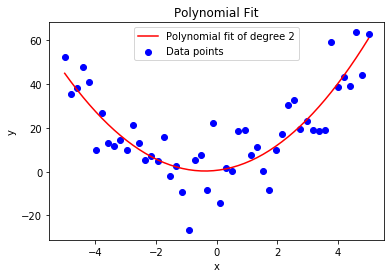

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 2 # <-------------------------- this is what you edit to change the degree 
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)

# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
                                 

In [9]:
# Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 108.8860
R-squared: 0.7236


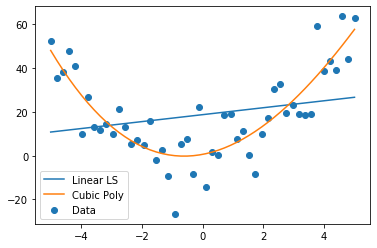

In [21]:
"""
Challenge A:
Fit the data points to Least Squares and Polyfit - start with a cubic polynomial - methods
We'll need to see the line and the polynomial
evaluate MSE and R-Squared for each method.
Have your code evaluate which is the better which method is better fit
"""

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate quadratic data
x = np.linspace(-5, 5, 50)
y = 2*x**2 + 3*x + np.random.randn(50)*10

# least squares
A = np.vstack([x, np.ones(len(x))]).T
m_ls, b_ls = np.linalg.lstsq(A, y, rcond=None)[0]
y_ls = m_ls*x + b_ls

# Polyfit
degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

plt.scatter(x, y, label="Data")
plt.plot(x, y_ls, label="Linear LS")
plt.plot(x, y_poly, label="Cubic Poly")
plt.legend()
plt.show()

In [27]:
"""
Challenge B:
Revisit your challenge from last Least Squares where you evaluated the Least Squares method
against using random vectors of X and Y.
Fit the data points to Least Squares and Polyfit - start with a cubic polynomial - methods
crank the polynomial up 1 degree at a time until it blatantly overfits
crank the polynomial down 1 dress at a time (keep it > 0) until it underfits
evaluate MSE and R-Squared for each run.
"""

my_m = 2.5 # my own equation 
my_c = -1

X = np.arange(0, 1.01, 0.01) # computing 0-1

noise = np.random.normal(0, 0.1, len(X))  # small random noise
Y = my_m * X + my_c + noise # y gets my equation + noise 

A = np.vstack([X, np.ones(len(X))]).T       # least squares 
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print(f"Original Equation: y = {my_m}x + {my_c}")
print(f"Slope: {m}, Intercept: {c}")

x_line = np.linspace(0, 1, 100) 
y_line = m * x_line + c

def mean_squared_error(actual_values, predicted_values):
    return np.mean((actual_values - predicted_values) ** 2)

def r_squared(actual_values, predicted_values):
    
    sum_squared_residuals = np.sum((actual_values - predicted_values) ** 2)
    total_sum_of_squares = np.sum((actual_values - np.mean(actual_values)) ** 2)
    
    r2 = 1 - (sum_squared_residuals / total_sum_of_squares)
    return r2

for degree in range(1, 11):

    polynomial_coefficients = np.polyfit(X, Y, degree)

    polynomial_function = np.poly1d(polynomial_coefficients)

    polynomial_predictions = polynomial_function(X)

    mse_value = mean_squared_error(Y, polynomial_predictions)

    r2_value = r_squared(y_values, polynomial_predictions)

    print(f"\nPolynomial Degree: {degree}")
    print("MSE:", mse_value)
    print("R²:", r2_value)


Original Equation: y = 2.5x + -1
Slope: 2.533129498779403, Intercept: -1.0264159189684983


NameError: name 'x_values' is not defined

In [25]:
"""
Challenge C:
Code the polynomial fit using the Vandermonde Matrix against the
same data points as in part A
"""

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)


# Create Vandermonde matrix for a polynomial
degree = 8

V = np.vander(x, N=degree+1, increasing=True)
polynomial = np.poly1d(coefficients[::-1])  # reverse the order
y_pred = polynomial(x)
print(V)


[[ 1.00000000e+00 -5.00000000e+00  2.50000000e+01 -1.25000000e+02
   6.25000000e+02 -3.12500000e+03  1.56250000e+04 -7.81250000e+04
   3.90625000e+05]
 [ 1.00000000e+00 -4.79591837e+00  2.30008330e+01 -1.10310117e+02
   5.29038318e+02 -2.53722459e+03  1.21683220e+04 -5.83582790e+04
   2.79881542e+05]
 [ 1.00000000e+00 -4.59183673e+00  2.10849646e+01 -9.68187150e+01
   4.44575732e+02 -2.04141918e+03  9.37386357e+03 -4.30432511e+04
   1.97647582e+05]
 [ 1.00000000e+00 -4.38775510e+00  1.92523948e+01 -8.44747937e+01
   3.70654707e+02 -1.62634208e+03  7.13599076e+03 -3.13109799e+04
   1.37384912e+05]
 [ 1.00000000e+00 -4.18367347e+00  1.75031237e+01 -7.32273542e+01
   3.06359339e+02 -1.28170744e+03  5.36224541e+03 -2.24338839e+04
   9.38560447e+04]
 [ 1.00000000e+00 -3.97959184e+00  1.58371512e+01 -6.30253976e+01
   2.50815358e+02 -9.98142750e+02  3.97220074e+03 -1.58077376e+04
   6.29083437e+04]
 [ 1.00000000e+00 -3.77551020e+00  1.42544773e+01 -5.38179245e+01
   2.03190123e+02 -7.6714638